In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

out = Path("output")
out.mkdir(exist_ok=True)

In [21]:
# NYC Open Data CSV endpoint for the dataset in the attached data dictionary
url = "https://data.cityofnewyork.us/resource/i6b5-j7bu.csv?$limit=500000"
df = pd.read_csv(url)

df.head()

,the_geom,segmentid,oft,onstreetname,fromstreetname,tostreetname,borough_code,work_start_date,work_end_date,uniqueid,purpose
0,MULTILINESTRING ((-74.25232394858968 40.505639...,69,570380525030546317,SHORE ROAD,CRAIG AVENUE,SATTERLEE STREET,S,2026-03-26T00:00:00.000,2026-04-30T00:00:00.000,38ee252bf14805bb1d74b113154c2b1b84cf3cec677d85...,DOT IN-HOUSE PAVING
1,MULTILINESTRING ((-74.25146174311145 40.505759...,71,570380520782525030,SHORE ROAD,BRYAN STREET,CRAIG AVENUE,S,2026-03-26T00:00:00.000,2026-04-30T00:00:00.000,cb2e58a8deff943f6210e70bca8d1526466f38e047c661...,DOT IN-HOUSE PAVING
2,MULTILINESTRING ((-74.23862565121732 40.506888...,359,529662525786548630,GEORGE STREET,DELIA COURT,SPRAGUE AVENUE,S,2026-03-26T00:00:00.000,2026-04-30T00:00:00.000,f5efec86cead1e683f48dbbc25b6ecace2be78f220bc85...,DOT IN-HOUSE PAVING
3,MULTILINESTRING ((-74.2505747163354 40.5058837...,73,570380520782524250,SHORE ROAD,BRYAN STREET,CONNECTICUT STREET,S,2026-03-26T00:00:00.000,2026-04-30T00:00:00.000,bbc29529fe3bd0ce759a970de86be3fbbce4f99b7bb4eb...,DOT IN-HOUSE PAVING
4,MULTILINESTRING ((-74.24879607173015 40.506115...,169,570380516910528525,SHORE ROAD,ASPINWALL STREET,FINLAY STREET,S,2026-03-26T00:00:00.000,2026-04-30T00:00:00.000,bede39a159d5239d1f74b02b34f93444214721a3e0feeb...,DOT IN-HOUSE PAVING


In [22]:
df.columns.tolist()

['the_geom',
 'segmentid',
 'oft',
 'onstreetname',
 'fromstreetname',
 'tostreetname',
 'borough_code',
 'work_start_date',
 'work_end_date',
 'uniqueid',
 'purpose']

In [31]:
for c in ["work_start_date", "work_end_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

months_keep = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

df_2018 = df[df["work_start_date"].dt.year == 2026].copy()
filtered = df_2018[df_2018["work_start_date"].dt.month.isin(months_keep)].copy()

filtered["duration_days"] = (filtered["work_end_date"] - filtered["work_start_date"]).dt.days
filtered["start_month"] = filtered["work_start_date"].dt.month_name()
filtered["start_weekday"] = filtered["work_start_date"].dt.day_name()
filtered["corridor"] = (
    filtered["onstreetname"].fillna("")
    + " between "
    + filtered["fromstreetname"].fillna("")
    + " and "
    + filtered["tostreetname"].fillna("")
).str.strip()

filtered.shape

(3705, 15)

## Basic checks

In [7]:
summary = {
    "rows_downloaded_total": int(len(df)),
    "rows_2017_selected_months": int(len(filtered)),
    "unique_segments": int(filtered["segmentid"].nunique() if "segmentid" in filtered.columns else np.nan),
    "unique_corridors": int(filtered["corridor"].nunique()),
    "min_start": filtered["work_start_date"].min(),
    "max_start": filtered["work_start_date"].max(),
    "missing_end_date": int(filtered["work_end_date"].isna().sum()),
    "median_duration_days": float(filtered["duration_days"].median()) if filtered["duration_days"].notna().any() else np.nan,
}

pd.Series(summary)

rows_downloaded_total        3705
rows_2017_selected_months       0
unique_segments                 0
unique_corridors                0
min_start                     NaT
max_start                     NaT
missing_end_date                0
median_duration_days          NaN
dtype: object

In [8]:
monthly = filtered["start_month"].value_counts().reindex(["June", "August", "October", "December"])
borough = filtered["borough_code"].fillna("Unknown").value_counts()
purpose = filtered["purpose"].fillna("Unknown").value_counts().head(15) if "purpose" in filtered.columns else pd.Series(dtype="int64")
weekday = filtered["start_weekday"].value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
top_corridors = filtered["corridor"].value_counts().head(15)

monthly, borough.head(), purpose.head(), weekday

(start_month
 June       NaN
 August     NaN
 October    NaN
 December   NaN
 Name: count, dtype: float64,
 Series([], Name: count, dtype: int64),
 Series([], Name: count, dtype: int64),
 start_weekday
 Monday      NaN
 Tuesday     NaN
 Wednesday   NaN
 Thursday    NaN
 Friday      NaN
 Saturday    NaN
 Sunday      NaN
 Name: count, dtype: float64)

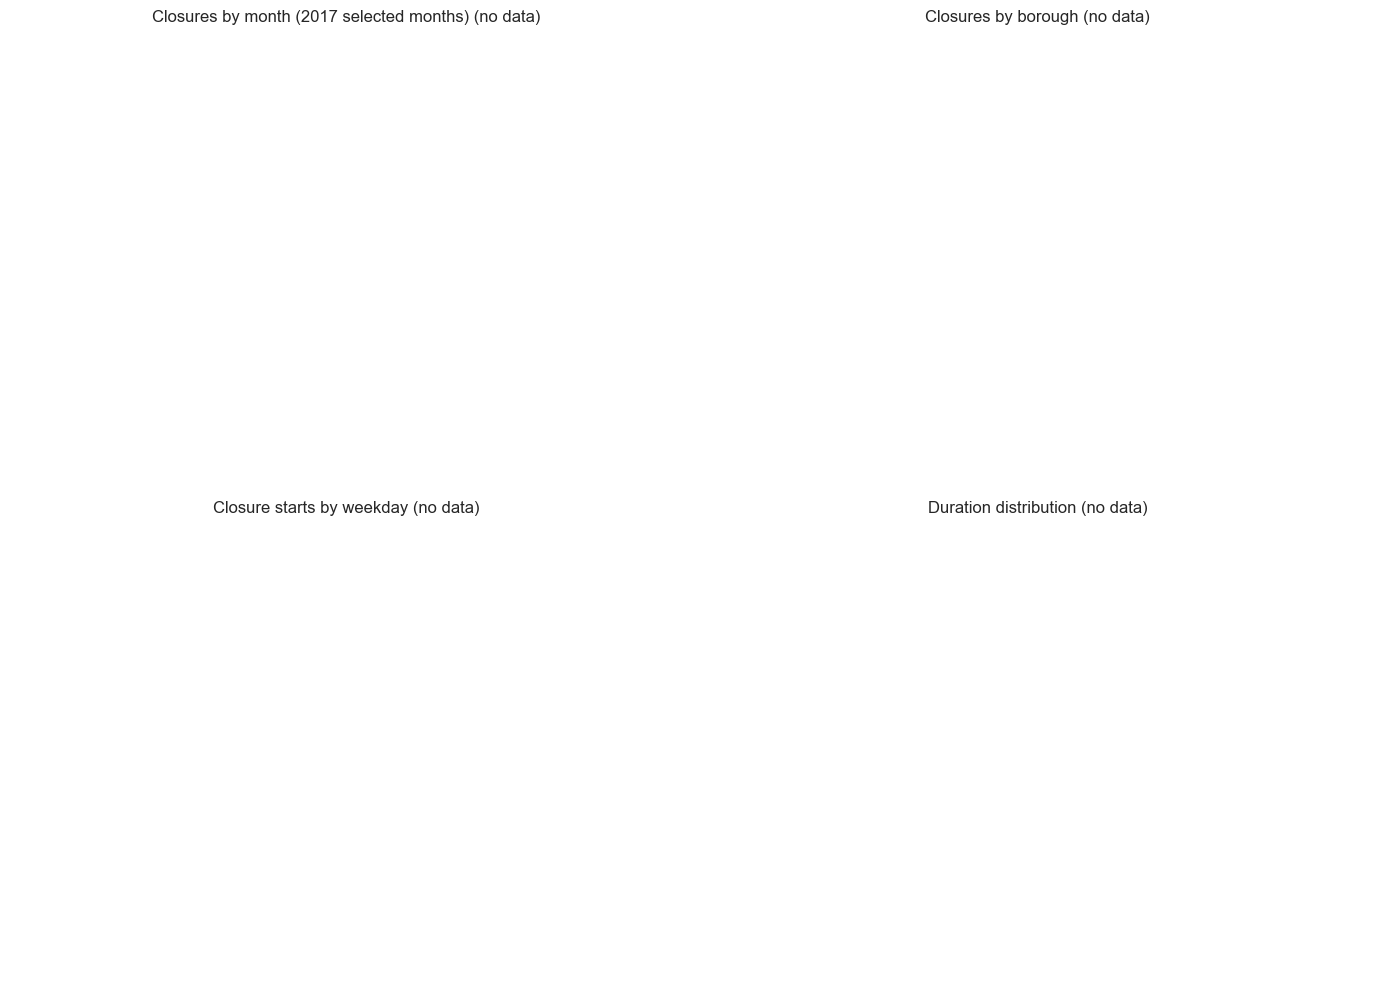

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plots = [
    (monthly, axes[0, 0], "bar", "#4C78A8", "Closures by month (2017 selected months)"),
    (borough, axes[0, 1], "bar", "#F58518", "Closures by borough"),
    (weekday, axes[1, 0], "bar", "#54A24B", "Closure starts by weekday"),
]

for series, ax, kind, color, title in plots:
    if series is not None and len(series.dropna()) > 0:
        series.dropna().plot(kind=kind, ax=ax, color=color, title=title)
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.set_title(title + " (no data)")
        ax.axis("off")

dur = filtered["duration_days"].dropna().clip(upper=120)
if len(dur) > 0:
    dur.plot(kind="hist", bins=30, ax=axes[1, 1], color="#E45756",
             title="Duration distribution (capped at 120 days)")
    axes[1, 1].set_xlabel("Days")
else:
    axes[1, 1].set_title("Duration distribution (no data)")
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
if not purpose.empty:
    plt.figure(figsize=(10, 6))
    purpose.sort_values().plot(
        kind="barh",
        color="#72B7B2",
        title="Top closure purposes"
    )
    plt.tight_layout()
    plt.show()

In [ ]:
top_corridors.to_frame("closure_count")

## Interpretation

Useful signals this dataset may add if joined to transit data:

- **Localized disruption intensity**: count of active closures near a route, stop, or street segment.
- **Closure duration**: longer permits may proxy sustained construction friction.
- **Spatial concentration**: repeated closures on the same corridor could indicate recurring risk areas.
- **Work type (`purpose`)**: some categories may be more disruptive than others.

Important limitation: because exact daily active hours are not included, this dataset is better as a **coarse disruption feature** than as a precise real-time obstruction label.

In [ ]:
filtered.to_csv(out / "street_closures_filtered_2017_selected_months.csv", index=False)
monthly.rename("count").to_csv(out / "street_closures_by_month.csv")
borough.rename("count").to_csv(out / "street_closures_by_borough.csv")
weekday.rename("count").to_csv(out / "street_closures_by_weekday.csv")
top_corridors.rename("count").to_csv(out / "street_closures_top_corridors.csv")

summary_df = pd.DataFrame([summary])
summary_df.to_csv(out / "street_closures_summary.csv", index=False)

summary_df